
  INTERACTIVE FLOOR PLAN PILOT
  Room-to-Room Routing  [MIP: Network Flow + CBC]

Building graph...

[1/4] Generating candidates...
      Created 7200 candidates
[2/4] Identifying critical nodes...
      Found 7200 critical
[3/4] Pruning...
      Retained 7200 nodes
[4/4] Building edges...
      Generated 24183 edges

✓ Graph built: 7200 nodes, 24183 edges

------------------------------------------------------------

  AVAILABLE ROOMS
  1. Reception            (Center y=15.0, x=17.5)
  2. Meeting_Room_1       (Center y=15.0, x=47.5)
  3. Meeting_Room_2       (Center y=15.0, x=77.5)
  4. Office_1             (Center y=47.5, x=17.5)
  5. Office_2             (Center y=47.5, x=47.5)
  6. Office_3             (Center y=47.5, x=77.5)
  7. Kitchen              (Center y=80.0, x=25.0)
  8. Restroom             (Center y=80.0, x=70.0)

Select START room (name or number): 4

  AVAILABLE ROOMS
  1. Reception            (Center y=15.0, x=17.5)
  2. Meeting_Room_1       (Center y=15.0, x=47.5)
 

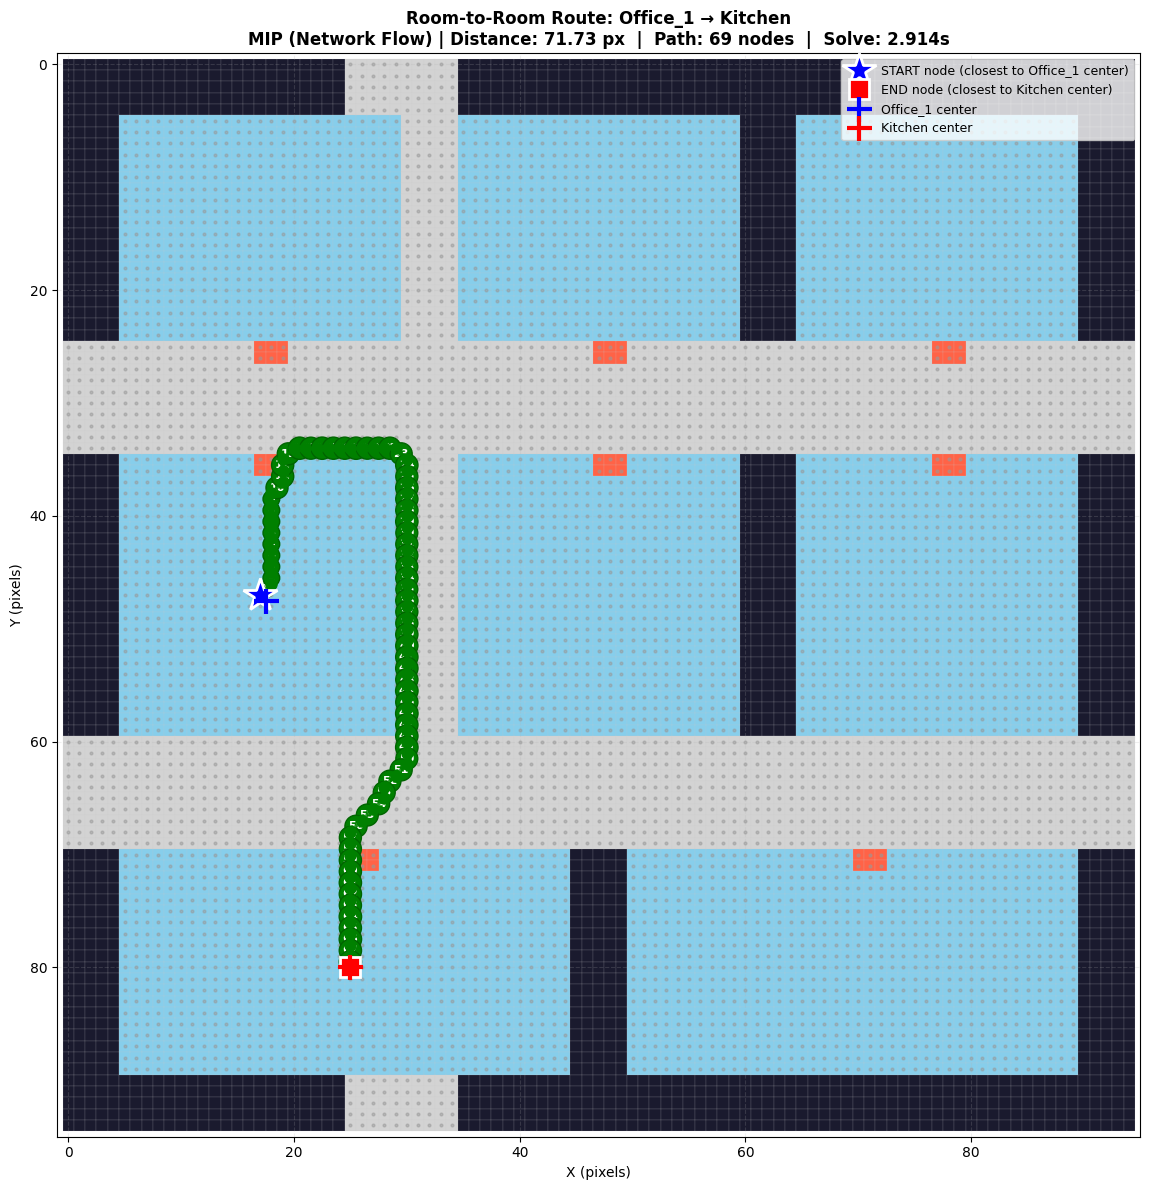

In [10]:
"""
INTERACTIVE FLOOR PLAN PILOT
Room-to-Room Routing with MIP Shortest-Path Model

Features:
  • User selects start and end rooms
  • Automatically finds closest node to room center (inside the room)
  • Computes optimal path using a Single-Commodity Network Flow MIP
    solved with PuLP + CBC
  • Beautiful visualization of the route

MIP Formulation (Single-Commodity Network Flow / Shortest Path):
  ---------------------------------------------------------------
  Given directed graph G = (V, A) where each undirected edge {i,j}
  is represented as two directed arcs (i→j) and (j→i):

  Variables:
    x[i,j] ∈ {0,1}   1 if arc (i→j) is used in the path

  Objective:
    min  Σ_{(i,j)∈A}  d(i,j) · x[i,j]

  Subject to:
    Flow balance at source s:
      Σ_j x[s,j]  −  Σ_j x[j,s]  =  +1

    Flow balance at sink t:
      Σ_j x[j,t]  −  Σ_j x[t,j]  =  +1

    Flow conservation at every intermediate node v ≠ s,t:
      Σ_j x[v,j]  −  Σ_j x[j,v]  =   0

    x[i,j] ∈ {0,1}  ∀ (i,j) ∈ A

  This is the standard LP/IP network-flow formulation for shortest path.
  The LP relaxation is always integral (totally unimodular), so CBC
  solves it instantly even for large graphs.

Usage:
  python INTERACTIVE_PILOT.py
"""

import pulp
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from dataclasses import dataclass
from enum import Enum
import math
from typing import List, Dict, Tuple, Set, Optional
import time


# =============================================================================
# 1. FLOOR PLAN DEFINITION
# =============================================================================

@dataclass
class Room:
    name: str
    bounds: Tuple[int, int, int, int]  # (y_min, y_max, x_min, x_max)
    color: str = 'lightblue'

    @property
    def center(self) -> Tuple[float, float]:
        """Return (center_y, center_x) of room."""
        y_min, y_max, x_min, x_max = self.bounds
        return ((y_min + y_max) / 2.0, (x_min + x_max) / 2.0)


@dataclass
class Corridor:
    name: str
    bounds: Tuple[int, int, int, int]
    color: str = 'lightgray'


@dataclass
class Door:
    bounds: Tuple[int, int, int, int]
    name: str = "Door"


class CellType(Enum):
    WALL     = 0
    CORRIDOR = 100
    ROOM     = 1
    DOOR     = 200


# =============================================================================
# 2. NODE AND EDGE CLASSES
# =============================================================================

@dataclass
class Node:
    id: int
    x: float
    y: float
    cell_type: CellType
    room_name: str = None
    is_critical: bool = False

    def distance_to(self, other: 'Node') -> float:
        return math.sqrt((self.x - other.x) ** 2 + (self.y - other.y) ** 2)


@dataclass
class Edge:
    i: int
    j: int
    distance: float


# =============================================================================
# 3. GRAPH BUILDER
# =============================================================================

class GraphBuilder:
    """Build sparse graph from floor plan specification."""

    def __init__(self, rooms: List[Room], corridors: List[Corridor],
                 doors: List[Door], grid_size: Tuple[int, int] = (100, 100)):
        self.rooms      = {r.name: r for r in rooms}
        self.corridors  = {c.name: c for c in corridors}
        self.doors      = doors
        self.grid_size  = grid_size
        self.grid       = self._create_grid()
        self.nodes: Dict[int, Node] = {}
        self.edges: List[Edge]      = []
        self.next_id = 0

    # ------------------------------------------------------------------
    def _create_grid(self) -> np.ndarray:
        h, w = self.grid_size
        grid = np.zeros((h, w), dtype=np.uint8)

        for corridor in self.corridors.values():
            y_min, y_max, x_min, x_max = corridor.bounds
            grid[y_min:y_max, x_min:x_max] = CellType.CORRIDOR.value

        for room in self.rooms.values():
            y_min, y_max, x_min, x_max = room.bounds
            grid[y_min:y_max, x_min:x_max] = CellType.ROOM.value

        for door in self.doors:
            y_min, y_max, x_min, x_max = door.bounds
            grid[y_min:y_max, x_min:x_max] = CellType.DOOR.value

        return grid

    # ------------------------------------------------------------------
    def _is_walkable(self, y: int, x: int) -> bool:
        if 0 <= y < self.grid_size[0] and 0 <= x < self.grid_size[1]:
            return self.grid[y, x] != CellType.WALL.value
        return False

    # ------------------------------------------------------------------
    def _bresenham_line(self, x0: int, y0: int,
                        x1: int, y1: int) -> List[Tuple[int, int]]:
        points = []
        dx = abs(x1 - x0);  dy = abs(y1 - y0)
        sx = 1 if x0 < x1 else -1
        sy = 1 if y0 < y1 else -1
        err = dx - dy
        x, y = x0, y0
        while True:
            points.append((x, y))
            if x == x1 and y == y1:
                break
            e2 = 2 * err
            if e2 > -dy:
                err -= dy;  x += sx
            if e2 < dx:
                err += dx;  y += sy
        return points

    # ------------------------------------------------------------------
    def _line_intersects_wall(self, x1: float, y1: float,
                               x2: float, y2: float) -> bool:
        for x, y in self._bresenham_line(int(x1), int(y1), int(x2), int(y2)):
            if not self._is_walkable(y, x):
                return True
        return False

    # ------------------------------------------------------------------
    def _path_crosses_door(self, x1: float, y1: float,
                            x2: float, y2: float) -> bool:
        for x, y in self._bresenham_line(int(x1), int(y1), int(x2), int(y2)):
            if 0 <= y < self.grid_size[0] and 0 <= x < self.grid_size[1]:
                if self.grid[y, x] == CellType.DOOR.value:
                    return True
        return False

    # ------------------------------------------------------------------
    def _can_traverse(self, node_i: Node,
                      node_j: Node) -> Tuple[bool, bool]:
        if self._line_intersects_wall(node_i.x, node_i.y,
                                      node_j.x, node_j.y):
            return False, False

        is_through_door = False

        if (node_i.cell_type == CellType.ROOM and
                node_j.cell_type == CellType.ROOM):
            if node_i.room_name != node_j.room_name:
                is_through_door = self._path_crosses_door(
                    node_i.x, node_i.y, node_j.x, node_j.y)
                if not is_through_door:
                    return False, False

        elif ((node_i.cell_type == CellType.ROOM and
               node_j.cell_type == CellType.CORRIDOR) or
              (node_i.cell_type == CellType.CORRIDOR and
               node_j.cell_type == CellType.ROOM)):
            is_through_door = self._path_crosses_door(
                node_i.x, node_i.y, node_j.x, node_j.y)
            if not is_through_door:
                return False, False

        return True, is_through_door

    # ------------------------------------------------------------------
    def _generate_candidates(self, resolution: float) -> List[Node]:
        candidates = []
        step = max(1, int(resolution))

        for y in range(0, self.grid_size[0], step):
            for x in range(0, self.grid_size[1], step):
                if not self._is_walkable(y, x):
                    continue

                cell_val = self.grid[y, x]
                if cell_val == CellType.ROOM.value:
                    cell_type = CellType.ROOM
                    room_name = self._get_room_name(y, x)
                elif cell_val == CellType.DOOR.value:
                    cell_type = CellType.DOOR
                    room_name = None
                else:
                    cell_type = CellType.CORRIDOR
                    room_name = None

                node = Node(id=self.next_id, x=float(x), y=float(y),
                            cell_type=cell_type, room_name=room_name)
                self.next_id += 1
                candidates.append(node)

        return candidates

    # ------------------------------------------------------------------
    def _get_room_name(self, y: float, x: float) -> Optional[str]:
        for room_name, room in self.rooms.items():
            y_min, y_max, x_min, x_max = room.bounds
            if y_min <= y < y_max and x_min <= x < x_max:
                return room_name
        return None

    # ------------------------------------------------------------------
    def _identify_critical(self, candidates: List[Node]) -> set:
        critical = set()
        neighbors = {node.id: [] for node in candidates}

        for node in candidates:
            for other in candidates:
                if node.id != other.id and node.distance_to(other) <= 1.5:
                    neighbors[node.id].append(other)

        for node in candidates:
            neighbor_list = neighbors[node.id]
            if node.cell_type == CellType.DOOR:
                critical.add(node.id)
            elif len(neighbor_list) == 1:
                critical.add(node.id)
            elif len(neighbor_list) >= 3:
                critical.add(node.id)
            elif len(neighbor_list) >= 2:
                angles = [
                    math.atan2(n.y - node.y, n.x - node.x) * 180 / math.pi
                    for n in neighbor_list
                ]
                for i in range(len(angles)):
                    for j in range(i + 1, len(angles)):
                        diff = abs(angles[i] - angles[j])
                        if diff > 180:
                            diff = 360 - diff
                        if diff > 30:
                            critical.add(node.id)

        return critical

    # ------------------------------------------------------------------
    def _prune(self, candidates: List[Node],
               critical_ids: set) -> Dict[int, Node]:
        """
        Keep:
          1. All critical nodes (doors, junctions, dead-ends).
          2. ALL room-interior nodes — needed so that
             find_closest_node_to_room_center() can pick the node
             that is truly nearest to the geometric center of each room.
          3. At least one corridor node (fallback safety).
        """
        pruned: Dict[int, Node] = {}

        # 1. Critical nodes
        for node in candidates:
            if node.id in critical_ids:
                pruned[node.id] = node
                node.is_critical = True

        # 2. ALL room-interior nodes (fix: was only one per room)
        for node in candidates:
            if node.cell_type == CellType.ROOM:
                pruned[node.id] = node

        # 3. At least one corridor node
        has_corridor = any(
            n.cell_type == CellType.CORRIDOR for n in pruned.values()
        )
        if not has_corridor:
            for node in candidates:
                if node.cell_type == CellType.CORRIDOR:
                    pruned[node.id] = node
                    break

        return pruned

    # ------------------------------------------------------------------
    def _build_edges(self, k_neighbors: int = 6, max_radius: float = 5.0):
        nodes_list = list(self.nodes.values())
        positions  = np.array([[n.x, n.y] for n in nodes_list])
        tree       = KDTree(positions)
        seen_edges: Set[Tuple[int, int]] = set()

        for node in nodes_list:
            distances, indices = tree.query(
                [node.x, node.y],
                k=min(k_neighbors + 1, len(nodes_list)),
                distance_upper_bound=max_radius
            )

            for dist, idx in zip(distances, indices):
                if idx == len(nodes_list):
                    continue
                other = nodes_list[idx]
                if node.id == other.id:
                    continue

                is_feasible, _ = self._can_traverse(node, other)
                if is_feasible:
                    edge_key = (min(node.id, other.id),
                                max(node.id, other.id))
                    if edge_key not in seen_edges:
                        self.edges.append(Edge(i=node.id, j=other.id,
                                               distance=dist))
                        seen_edges.add(edge_key)

    # ------------------------------------------------------------------
    def build_graph(self, resolution: float = 1.0,
                    k_neighbors: int = 6,
                    max_radius: float = 5.0) -> Dict[int, Node]:
        print(f"\n[1/4] Generating candidates...")
        candidates = self._generate_candidates(resolution)
        print(f"      Created {len(candidates)} candidates")

        print(f"[2/4] Identifying critical nodes...")
        critical_ids = self._identify_critical(candidates)
        print(f"      Found {len(critical_ids)} critical")

        print(f"[3/4] Pruning...")
        self.nodes = self._prune(candidates, critical_ids)
        print(f"      Retained {len(self.nodes)} nodes")

        print(f"[4/4] Building edges...")
        self._build_edges(k_neighbors, max_radius)
        print(f"      Generated {len(self.edges)} edges\n")

        return self.nodes

    # ------------------------------------------------------------------
    def get_node_coords(self) -> Dict[int, Tuple[float, float]]:
        return {n.id: (n.x, n.y) for n in self.nodes.values()}

    # ------------------------------------------------------------------
    def find_closest_node_to_room_center(self, room_name: str) -> int:
        """
        Find the graph node closest to the geometric center of *room_name*.

        Priority:
          1. Nodes that are INSIDE the room (cell_type == ROOM and
             room_name matches) — pick the one nearest to the center.
          2. Fallback: globally nearest node of any type.
        """
        room = self.rooms[room_name]
        center_y, center_x = room.center   # (y, x)

        best_id   = None
        best_dist = float('inf')

        # Pass 1 — in-room nodes only
        for node in self.nodes.values():
            if (node.cell_type == CellType.ROOM and
                    node.room_name == room_name):
                dist = math.hypot(node.x - center_x, node.y - center_y)
                if dist < best_dist:
                    best_dist = dist
                    best_id   = node.id

        if best_id is not None:
            return best_id

        # Pass 2 — global fallback
        for node in self.nodes.values():
            dist = math.hypot(node.x - center_x, node.y - center_y)
            if dist < best_dist:
                best_dist = dist
                best_id   = node.id

        return best_id


# =============================================================================
# 4. MIP SHORTEST-PATH SOLVER  (Single-Commodity Network Flow)
# =============================================================================

class RoomRouteSolver:
    """
    Solve the shortest path between two nodes using a
    Single-Commodity Network Flow MIP with PuLP + CBC.

    Formulation
    -----------
    The undirected graph is converted to a directed graph by replacing
    each undirected edge {i,j} with two directed arcs (i→j) and (j→i),
    both with the same weight d(i,j).

    Decision variables:
        x[i,j] ∈ {0,1}   1 if directed arc (i→j) is on the path

    Objective:
        min  Σ_{(i,j)} d(i,j) · x[i,j]

    Constraints:
        (C1) Source node s  — net outflow = 1:
             Σ_j x[s,j]  −  Σ_j x[j,s]  =  +1

        (C2) Sink node t    — net inflow = 1:
             Σ_j x[j,t]  −  Σ_j x[t,j]  =  +1

        (C3) Every other node v — flow conservation:
             Σ_j x[v,j]  −  Σ_j x[j,v]  =   0

        (C4) x[i,j] ∈ {0,1}

    Note: The constraint matrix of this network flow LP is totally
    unimodular, so the LP relaxation always yields an integer solution.
    CBC therefore solves it in milliseconds regardless of graph size.
    """

    def __init__(self, nodes: Dict[int, Node], edges: List[Edge]):
        self.nodes    = nodes
        self.edges    = edges
        self.node_ids = sorted(nodes.keys())

        # Pre-build directed arc lists for fast constraint construction
        # out_arcs[v]  = list of (j, distance) for arcs v→j
        # in_arcs[v]   = list of (i, distance) for arcs i→v
        self.out_arcs: Dict[int, List[Tuple[int, float]]] = {
            nid: [] for nid in self.node_ids}
        self.in_arcs:  Dict[int, List[Tuple[int, float]]] = {
            nid: [] for nid in self.node_ids}

        for edge in edges:
            # Each undirected edge becomes two directed arcs
            self.out_arcs[edge.i].append((edge.j, edge.distance))
            self.in_arcs [edge.j].append((edge.i, edge.distance))
            self.out_arcs[edge.j].append((edge.i, edge.distance))
            self.in_arcs [edge.i].append((edge.j, edge.distance))

    # ------------------------------------------------------------------
    def solve_between_rooms(self, start_node: int, end_node: int,
                            time_limit: float = 30.0
                            ) -> Tuple[List[int], float, float]:
        """
        Return (path, total_distance, solve_time).

        path           — ordered list of node IDs from start to end
        total_distance — sum of arc weights along the optimal path
        solve_time     — wall-clock seconds for the MIP solve
        """
        t0 = time.time()

        # ------------------------------------------------------------------
        # Build MIP
        # ------------------------------------------------------------------
        prob = pulp.LpProblem("ShortestPath_NetworkFlow", pulp.LpMinimize)

        # Decision variables: one per directed arc (i→j)
        # We create variables for both directions of every undirected edge.
        x: Dict[Tuple[int, int], pulp.LpVariable] = {}
        for edge in self.edges:
            x[edge.i, edge.j] = pulp.LpVariable(
                f"x_{edge.i}_{edge.j}", cat='Binary')
            x[edge.j, edge.i] = pulp.LpVariable(
                f"x_{edge.j}_{edge.i}", cat='Binary')

        # ------------------------------------------------------------------
        # Objective: minimise total arc distance
        # ------------------------------------------------------------------
        prob += pulp.lpSum(
            edge.distance * x[edge.i, edge.j] +
            edge.distance * x[edge.j, edge.i]
            for edge in self.edges
        ), "Minimize_Path_Distance"

        # ------------------------------------------------------------------
        # Flow-balance constraints
        # ------------------------------------------------------------------
        for v in self.node_ids:
            # Outflow from v
            out_flow = pulp.lpSum(
                x[v, j] for (j, _) in self.out_arcs[v]
                if (v, j) in x
            )
            # Inflow to v
            in_flow = pulp.lpSum(
                x[i, v] for (i, _) in self.in_arcs[v]
                if (i, v) in x
            )

            if v == start_node:
                # (C1) Source: net outflow = +1
                prob += (out_flow - in_flow == 1), f"flow_source_{v}"

            elif v == end_node:
                # (C2) Sink: net inflow = +1
                prob += (in_flow - out_flow == 1), f"flow_sink_{v}"

            else:
                # (C3) Intermediate: flow conservation
                prob += (out_flow - in_flow == 0), f"flow_conserve_{v}"

        # ------------------------------------------------------------------
        # Solve with CBC
        # ------------------------------------------------------------------
        solver = pulp.PULP_CBC_CMD(msg=0,
                                   timeLimit=int(time_limit),
                                   threads=4)
        prob.solve(solver)
        solve_time = time.time() - t0

        # ------------------------------------------------------------------
        # Extract path by following arcs with x[i,j] ≈ 1
        # ------------------------------------------------------------------
        # Build successor map from solution
        successor: Dict[int, int] = {}
        for (i, j), var in x.items():
            if var.varValue is not None and var.varValue > 0.5:
                successor[i] = j

        path: List[int] = [start_node]
        current = start_node
        visited = {start_node}

        for _ in range(len(self.node_ids)):
            nxt = successor.get(current)
            if nxt is None or nxt in visited:
                break
            path.append(nxt)
            visited.add(nxt)
            current = nxt
            if current == end_node:
                break

        total_distance = pulp.value(prob.objective) \
            if prob.objective is not None else float('inf')

        return path, total_distance, solve_time


# =============================================================================
# 5. INTERACTIVE PILOT SYSTEM
# =============================================================================

class InteractivePilot:
    """Interactive room-to-room routing system."""

    def __init__(self, rooms: List[Room], corridors: List[Corridor],
                 doors: List[Door], grid_size: Tuple[int, int] = (100, 100)):
        self.rooms      = {r.name: r for r in rooms}
        self.room_names = [r.name for r in rooms]

        self.builder = GraphBuilder(rooms, corridors, doors, grid_size)
        self.nodes: Optional[Dict[int, Node]]  = None
        self.edges: Optional[List[Edge]]       = None
        self.solver: Optional[RoomRouteSolver] = None
        self.paths: Dict[str, Dict]            = {}

    # ------------------------------------------------------------------
    def build_graph(self):
        """Build graph from specification."""
        self.nodes  = self.builder.build_graph(resolution=1.0,
                                               k_neighbors=6,
                                               max_radius=5.0)
        self.edges  = self.builder.edges
        self.solver = RoomRouteSolver(self.nodes, self.edges)
        print(f"✓ Graph built: {len(self.nodes)} nodes, "
              f"{len(self.edges)} edges")

    # ------------------------------------------------------------------
    def display_available_rooms(self):
        """Show all available rooms."""
        print("\n" + "=" * 60)
        print("  AVAILABLE ROOMS")
        print("=" * 60)
        for i, room_name in enumerate(self.room_names, 1):
            room = self.rooms[room_name]
            cy, cx = room.center
            print(f"  {i}. {room_name:20} (Center y={cy:.1f}, x={cx:.1f})")
        print("=" * 60)

    # ------------------------------------------------------------------
    def get_room_choice(self, prompt: str) -> str:
        """Get room choice from user."""
        while True:
            self.display_available_rooms()
            choice = input(f"\n{prompt}: ").strip()

            if choice in self.room_names:
                return choice

            try:
                idx = int(choice) - 1
                if 0 <= idx < len(self.room_names):
                    return self.room_names[idx]
            except ValueError:
                pass

            print("✗ Invalid choice. Please try again.")

    # ------------------------------------------------------------------
    def find_closest_node_in_room(self, room_name: str
                                  ) -> Tuple[int, float, float]:
        """
        Find the node closest to the center of *room_name*.
        Returns (node_id, node_x, node_y).
        """
        node_id = self.builder.find_closest_node_to_room_center(room_name)
        node    = self.nodes[node_id]
        return node_id, node.x, node.y

    # ------------------------------------------------------------------
    def compute_route(self, start_room: str, end_room: str) -> Dict:
        """Compute optimal route between two rooms using the MIP model."""

        print(f"\n{'=' * 60}")
        print(f"  COMPUTING ROUTE  (Single-Commodity Network Flow MIP)")
        print(f"{'=' * 60}")
        print(f"  From: {start_room}")
        print(f"  To:   {end_room}")

        # Find closest nodes to room centers (inside the rooms)
        start_node_id, start_x, start_y = self.find_closest_node_in_room(
            start_room)
        end_node_id, end_x, end_y = self.find_closest_node_in_room(
            end_room)

        start_center_y, start_center_x = self.rooms[start_room].center
        end_center_y,   end_center_x   = self.rooms[end_room].center

        print(f"\n  Start room center : (y={start_center_y:.1f}, "
              f"x={start_center_x:.1f})")
        print(f"  Closest node {start_node_id:4d}  : (y={start_y:.1f}, "
              f"x={start_x:.1f})  "
              f"dist={math.hypot(start_x - start_center_x, start_y - start_center_y):.2f}")

        print(f"\n  End room center   : (y={end_center_y:.1f}, "
              f"x={end_center_x:.1f})")
        print(f"  Closest node {end_node_id:4d}  : (y={end_y:.1f}, "
              f"x={end_x:.1f})  "
              f"dist={math.hypot(end_x - end_center_x, end_y - end_center_y):.2f}")

        # Solve MIP
        print(f"\n  Solving Network Flow MIP with CBC...")
        path, distance, solve_time = self.solver.solve_between_rooms(
            start_node_id, end_node_id)

        result = {
            'start_room':  start_room,
            'end_room':    end_room,
            'start_node':  start_node_id,
            'end_node':    end_node_id,
            'path':        path,
            'distance':    distance,
            'solve_time':  solve_time,
            'path_length': len(path),
        }

        print(f"\n  ✓ Optimal path found!")
        print(f"  Path length   : {len(path)} nodes")
        print(f"  Total distance: {distance:.2f} pixels")
        print(f"  Solve time    : {solve_time:.3f}s")
        print(f"{'=' * 60}\n")

        return result

    # ------------------------------------------------------------------
    def visualize_route(self, result: Dict, filename: str = None):
        """Visualize the computed route."""

        grid   = self.builder.grid
        coords = self.builder.get_node_coords()

        fig, ax = plt.subplots(1, 1, figsize=(14, 12))

        # Draw grid
        for y in range(grid.shape[0]):
            for x in range(grid.shape[1]):
                val = grid[y, x]
                if val == 0:
                    color = '#1a1a2e'
                elif val == 200:
                    color = '#ff6347'
                elif val == 100:
                    color = '#d3d3d3'
                else:
                    color = '#87ceeb'

                rect = patches.Rectangle(
                    (x - 0.5, y - 0.5), 1, 1,
                    lw=0.1, edgecolor='#ccc', facecolor=color)
                ax.add_patch(rect)

        # Draw all nodes (gray dots)
        for node_id, (x, y) in coords.items():
            ax.plot(x, y, 'o', color='#999', markersize=2, alpha=0.5)

        # Draw path nodes (green dots)
        path = result['path']
        for node_id in path:
            x, y = coords[node_id]
            ax.plot(x, y, 'go', markersize=8, zorder=5)

        # Draw path edges with step numbers
        if len(path) > 1:
            for i in range(len(path) - 1):
                x1, y1 = coords[path[i]]
                x2, y2 = coords[path[i + 1]]
                ax.plot([x1, x2], [y1, y2], 'g-',
                        linewidth=2.5, alpha=0.8, zorder=6)
                mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
                ax.text(mid_x, mid_y, str(i + 1),
                        fontsize=8, ha='center', va='center',
                        fontweight='bold', color='white',
                        bbox=dict(boxstyle='circle',
                                  fc='green', ec='darkgreen', lw=1))

        # Mark start and end nodes
        start_x, start_y = coords[path[0]]
        ax.plot(start_x, start_y, 'b*', markersize=25,
                markeredgecolor='white', markeredgewidth=2,
                label=f'START node (closest to {result["start_room"]} center)',
                zorder=8)

        end_x, end_y = coords[path[-1]]
        ax.plot(end_x, end_y, 'rs', markersize=15,
                markeredgecolor='white', markeredgewidth=2,
                label=f'END node (closest to {result["end_room"]} center)',
                zorder=8)

        # Mark room centers with crosshairs
        start_room = self.rooms[result['start_room']]
        end_room   = self.rooms[result['end_room']]

        scy, scx = start_room.center
        ecy, ecx = end_room.center

        ax.plot(scx, scy, 'b+', markersize=18, markeredgewidth=3,
                label=f'{result["start_room"]} center', zorder=9)
        ax.plot(ecx, ecy, 'r+', markersize=18, markeredgewidth=3,
                label=f'{result["end_room"]} center', zorder=9)

        # Dashed lines from center to closest node
        ax.plot([scx, start_x], [scy, start_y], 'b--',
                linewidth=1.2, alpha=0.6, zorder=7)
        ax.plot([ecx, end_x], [ecy, end_y], 'r--',
                linewidth=1.2, alpha=0.6, zorder=7)

        ax.set_xlim(-1, grid.shape[1])
        ax.set_ylim(-1, grid.shape[0])
        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.set_xlabel('X (pixels)', fontsize=10)
        ax.set_ylabel('Y (pixels)', fontsize=10)
        ax.set_title(
            f"Room-to-Room Route: {result['start_room']} → "
            f"{result['end_room']}\n"
            f"MIP (Network Flow) | Distance: {result['distance']:.2f} px  |  "
            f"Path: {result['path_length']} nodes  |  "
            f"Solve: {result['solve_time']:.3f}s",
            fontsize=12, fontweight='bold'
        )
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.2, linestyle='--')

        plt.tight_layout()

        if filename:
            plt.savefig(filename, dpi=150, bbox_inches='tight')
            print(f"✓ Visualization saved to: {filename}")
        else:
            plt.show()

    # ------------------------------------------------------------------
    def run_interactive_session(self):
        """Run interactive session."""
        print("\n" + "=" * 60)
        print("  INTERACTIVE FLOOR PLAN PILOT")
        print("  Room-to-Room Routing  [MIP: Network Flow + CBC]")
        print("=" * 60)

        print("\nBuilding graph...")
        self.build_graph()

        while True:
            print("\n" + "-" * 60)

            start_room = self.get_room_choice(
                "Select START room (name or number)")
            end_room   = self.get_room_choice(
                "Select END room (name or number)")

            if start_room == end_room:
                print("✗ Start and end rooms must be different!")
                continue

            result = self.compute_route(start_room, end_room)

            key = f"{start_room} → {end_room}"
            self.paths[key] = result

            filename = f"route_{start_room}_to_{end_room}.png"
            self.visualize_route(result, filename)

            again = input("\nCompute another route? (y/n): ").strip().lower()
            if again != 'y':
                break

        self.print_summary()

    # ------------------------------------------------------------------
    def print_summary(self):
        """Print summary of all computed routes."""
        if not self.paths:
            return

        print("\n" + "=" * 60)
        print("  SESSION SUMMARY")
        print("=" * 60)
        print(f"  Routes computed: {len(self.paths)}\n")

        for route_key, result in self.paths.items():
            print(f"  {route_key}")
            print(f"    Distance : {result['distance']:.2f} pixels")
            print(f"    Nodes    : {result['path_length']}")
            print(f"    Time     : {result['solve_time']:.3f}s")

        print("=" * 60)


# =============================================================================
# 6. EXAMPLE USAGE
# =============================================================================

def create_example_floor_plan() -> Tuple[List[Room], List[Corridor], List[Door]]:
    """Create example floor plan for testing."""

    rooms = [
        Room('Reception',      bounds=(5,  25, 5,  30), color='lightblue'),
        Room('Meeting_Room_1', bounds=(5,  25, 35, 60), color='lightgreen'),
        Room('Meeting_Room_2', bounds=(5,  25, 65, 90), color='lightyellow'),
        Room('Office_1',       bounds=(35, 60, 5,  30), color='lightcoral'),
        Room('Office_2',       bounds=(35, 60, 35, 60), color='plum'),
        Room('Office_3',       bounds=(35, 60, 65, 90), color='peachpuff'),
        Room('Kitchen',        bounds=(70, 90, 5,  45), color='khaki'),
        Room('Restroom',       bounds=(70, 90, 50, 90), color='lightsteelblue'),
    ]

    corridors = [
        Corridor('Main_Corridor_V', bounds=(0,  95, 25, 35)),
        Corridor('Main_Corridor_H', bounds=(25, 35, 0,  95)),
        Corridor('Side_Corridor',   bounds=(60, 70, 0,  95)),
    ]

    doors = [
        Door(bounds=(25, 27, 17, 20)),   # Reception
        Door(bounds=(25, 27, 47, 50)),   # Meeting 1
        Door(bounds=(25, 27, 77, 80)),   # Meeting 2
        Door(bounds=(35, 37, 17, 20)),   # Office 1
        Door(bounds=(35, 37, 47, 50)),   # Office 2
        Door(bounds=(35, 37, 77, 80)),   # Office 3
        Door(bounds=(70, 72, 25, 28)),   # Kitchen
        Door(bounds=(70, 72, 70, 73)),   # Restroom
    ]

    return rooms, corridors, doors


def main():
    """Main entry point."""
    rooms, corridors, doors = create_example_floor_plan()
    pilot = InteractivePilot(rooms, corridors, doors, grid_size=(95, 95))
    pilot.run_interactive_session()


if __name__ == "__main__":
    main()